# Working with complicated dataset

Created by ANH TRAN (015621450)  
Last updated: 3/18/26

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

NOTE: I first looked at the raw dataframe file with no changes in order to see the formatting before modifying the dataframe, which is "blast_results"

In [1]:
### Your code here . . .
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
blast_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"
blast_results_raw = pd.read_csv(blast_file)

blast_results_raw.head(10)



,# blastp,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,# Iteration: 0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,# Query: YP_220550.1 NADH dehydrogenase subuni...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# RID: 9SW3UNUT015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# Database: nr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Fields: query acc.ver, subject acc.ver, % id...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# 100 hits found,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,YP_220550.1,NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9,NaN
7,YP_220550.1,AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47,NaN
8,YP_220550.1,YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13,NaN
9,YP_220550.1,ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41,NaN


In [2]:
fields_line = blast_results_raw.iloc[4, 0]
print(fields_line)

# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications


In [3]:
my_columns = ["query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches", "gap opens", "q. start", "q. end", "s. start", "s. end", "evalue", "bit score", "% positives", "bonds", "publications"]
blast_results = pd.read_csv(
            blast_file,
            skiprows=7,
            header=None,
            names=my_columns,
            usecols=my_columns,
            thousands=','
)
blast_results.drop("query acc.ver", axis=1, inplace=True)
blast_results.set_index("subject acc.ver", inplace=True)
blast_results.index = blast_results.index.astype(str)
blast_results.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3


In [4]:
blast_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    int64  
 12  publications      100 non-null    object 
dtypes: float64(2), int64(10), object(1)
memory usage: 10.9+ KB


### Question 2
What is the average number of publications?

In [5]:
blast_results['publications'] = pd.to_numeric(blast_results['publications'], errors='coerce')
average_publication = blast_results['publications'].mean()
average_publication


26.989690721649485

ANSWER: THe average number of publications is 26.989690721649485, but if we round to the nearest number then it is 27

In [6]:
blast_results.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    int64  
 12  publications      97 non-null     float64
dtypes: float64(3), int64(10)
memory usage: 10.9+ KB


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [7]:
blast_results['bonds'] = pd.to_numeric(blast_results['bonds'], errors='coerce')
over_15k_bonds = blast_results[blast_results['bonds'] > 15000]
over_15k_bonds

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0
6G2J_H,100.000,317,0,0,2,318,2,318,0,626,100.00,15663,29.0
YP_002791042.1,99.057,318,3,0,1,318,1,318,0,625,99.69,15830,37.0
AGK29634.1,99.057,318,3,0,1,318,1,318,0,623,99.69,17381,14.0
0806162F,100.000,315,0,0,4,318,1,315,0,622,100.00,17499,43.0
YP_009112408.1,97.170,318,9,0,1,318,1,318,0,615,99.37,16861,46.0
YP_001876469.1,96.855,318,10,0,1,318,1,318,0,613,99.06,16274,22.0
YP_009092269.1,96.226,318,12,0,1,318,1,318,0,610,98.11,16170,47.0


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

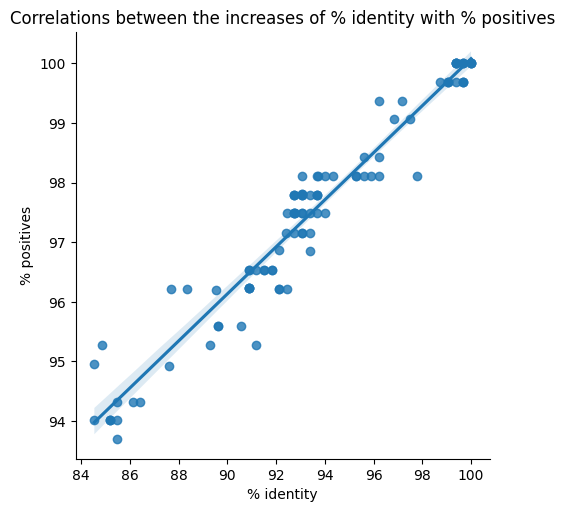

In [8]:
sns.lmplot(
    data = blast_results,
    x = "% identity",
    y = "% positives"
)

plt.title("Correlations between the increases of % identity with % positives");

ANSWER: Based on the plot, we can see that there are a postitive correlation between % identity and % positives based on the linear regression line. As the % identity increases, the % positives also increases around the same rate.

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [9]:
protein_source_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"

protein_source = pd.read_csv(protein_source_file)

protein_source.head()


,Unnamed: 0,Protein,Source
0,0,NP_904328.1,RefSeq
1,2,YP_220563.1,GenPept
2,12,YP_002791042.1,GenPept
3,13,YP_001686698.1,GenPept
4,21,YP_009112408.1,GenPept


In [10]:
blast_results = blast_results.reset_index()
blast_results = blast_results.merge(protein_source[["Protein", "Source"]], how="left", left_on="subject acc.ver", right_on="Protein")
blast_results.drop(columns=["Protein"], inplace=True)
blast_results.rename(columns={'Source' : 'Protein source'}, inplace=True)
blast_results = blast_results.set_index('subject acc.ver')
blast_results

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318,23,0,1,318,1,318,0,551,97.48,17348,6.0,NaN
ASP44815.1,93.375,317,21,0,1,317,1,317,0,551,96.85,7105,19.0,NaN
YP_009414156.1,84.543,317,49,0,1,317,1,317,0,551,94.01,18940,37.0,GenPept
